# Transformer for Time Series Forecasting

This notebook builds a small Transformer encoder (positional encoding + multi-head self-attention) from scratch to forecast a synthetic **multivariate** daily retail dataset — `value` (revenue), `customers`, `invoice_count`, `units`, and `discount` — then uses it to predict several years ahead.

**Key ideas:**
1. The trending columns (`value`, `customers`, `invoice_count`, `units`) grow over time, and neural nets (including Transformers) don't extrapolate trends well beyond what they saw in training. So we **detrend** each of them first — model only the stationary part (seasonality + noise) — and add the trend back after predicting.
2. The model uses ALL 5 features as input (multivariate input) but only predicts `value` (univariate output) — `customers`, `invoice_count`, `units`, and `discount` act as extra predictive context.

In [1]:
import numpy as np               # NumPy: numerical arrays and math operations (used for sine waves, arrays, etc.)
import pandas as pd              # Pandas: tabular / time-indexed data (DataFrames)
import matplotlib.pyplot as plt  # Matplotlib: plotting charts

np.random.seed(42)  # Fix the random seed so the "random" noise we generate is identical every time we re-run this notebook (reproducibility)


In [2]:
# Generate a synthetic daily MULTIVARIATE retail dataset: customers -> invoices -> units -> revenue,
# plus an independent discount signal. All of these are correlated with each other (like a real store)
# so the extra columns actually carry useful signal for forecasting `value` (revenue), not just noise.

n_days = (365*(2026-2010))  # Total days to simulate: 16 years * 365 = 5840 days
dates = pd.date_range(start="2010-01-01", periods=n_days, freq="D")  # 5840 consecutive calendar dates, one per day, starting 2010-01-01

t = np.arange(n_days)  # [0, 1, 2, ..., n_days-1] — a simple "day counter" used as the x-axis for every formula below

# --- customers: how many unique shoppers visit that day ---
customers_trend = 0.05 * t                                   # slowly growing customer base over the 16 years
customers_weekly = 20 * np.sin(2 * np.pi * t / 7)             # more shoppers on some days of the week than others
customers_yearly = 40 * np.sin(2 * np.pi * t / 365.25)        # seasonal footfall (e.g. festive months)
customers = 200 + customers_trend + customers_weekly + customers_yearly + np.random.normal(0, 10, n_days)
customers = np.clip(customers, 1, None)  # can't have negative/zero customers

# --- invoice_count: number of transactions, roughly proportional to customers (not every customer buys) ---
invoice_count = customers * 1.1 + np.random.normal(0, 5, n_days)
invoice_count = np.clip(invoice_count, 0, None)

# --- units: total items sold, roughly proportional to invoice_count (a few items per invoice) ---
units = invoice_count * 3 + np.random.normal(0, 8, n_days)
units = np.clip(units, 0, None)

# --- discount: average discount % that day — independent of footfall (e.g. planned promotions), no trend ---
discount = 12 + 5 * np.sin(2 * np.pi * t / 7) + np.random.normal(0, 1.5, n_days)
discount = np.clip(discount, 0, 30)  # keep discount in a realistic 0-30% band

# --- value: revenue = units sold * unit price, reduced by the discount that day ---
unit_price = 0.3
value = units * unit_price * (1 - discount / 100) + np.random.normal(0, 3, n_days)

df = pd.DataFrame({
    "date": dates,
    "value": value,                    # target we want to forecast (revenue)
    "customers": customers,            # predictor feature
    "invoice_count": invoice_count,    # predictor feature
    "units": units,                    # predictor feature
    "discount": discount,              # predictor feature
})
df.set_index("date", inplace=True)     # Make "date" the row index instead of a normal column (standard for time series)
print(df.shape)  # (rows, columns) — sanity check: should be (5840, 5)
df.head()


(5840, 5)


,value,customers,invoice_count,units,discount
date,,,,,
2010-01-01,178.609792,204.967142,227.255578,673.841502,12.180525
2010-01-02,166.545447,214.992050,230.508465,689.231621,16.989843
2010-01-03,190.206602,227.451366,242.728954,743.802294,15.586760
2010-01-04,172.237697,226.121348,238.113745,714.964733,16.712692
2010-01-05,186.296145,191.931008,214.729093,653.650484,6.759831


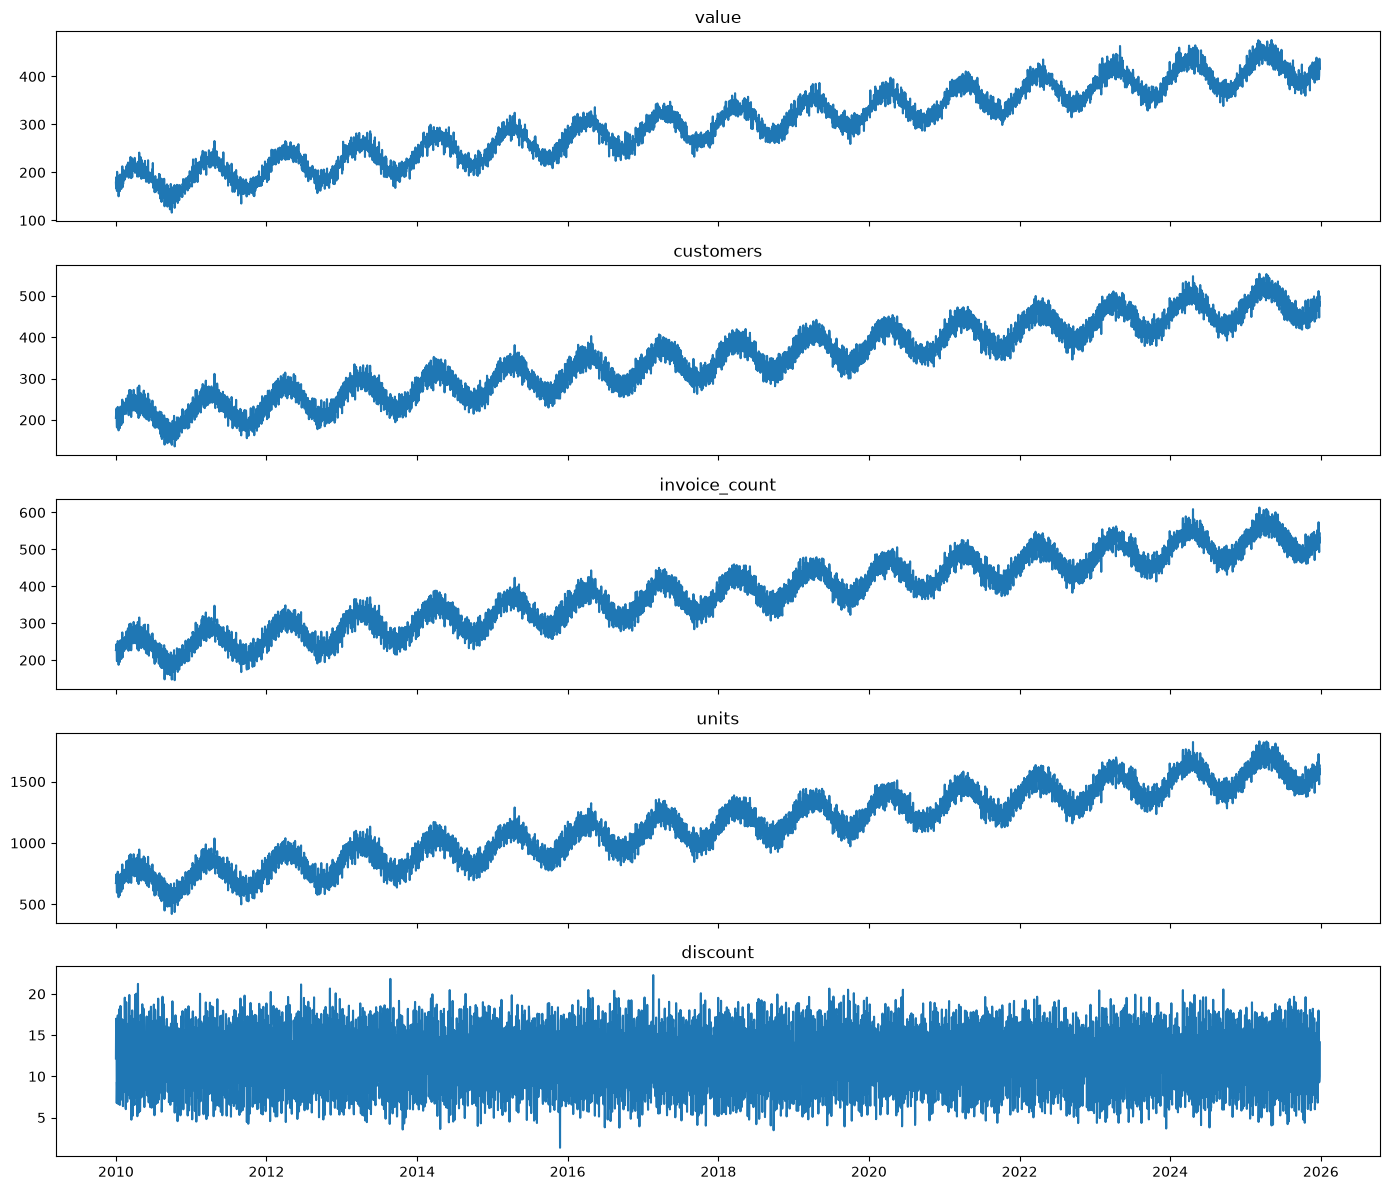

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)  # 5 stacked subplots (one per column), sharing the date axis

for ax, col in zip(axes, ["value", "customers", "invoice_count", "units", "discount"]):
    ax.plot(df.index, df[col])
    ax.set_title(col)

plt.tight_layout()  # Auto-adjust spacing so labels/titles don't get cut off


## Detrend the series

`value`, `customers`, `invoice_count`, and `units` all have a linear upward trend. If we feed raw values straight into the model, MinMax-scaled test/future values will fall outside the [0, 1] range the model trained on — Transformers (like most NNs) don't extrapolate trends well beyond what they've seen.

**Fix:** fit a straight line to each trending column's trend using only the training portion (to avoid leakage), subtract it to get a stationary residual (seasonality + noise), model *that*, and add the trend back after predicting. `discount` has no trend by construction, so it's used as-is.

In [4]:
# Fit a linear trend on the TRAINING portion only (avoid leakage), then remove it from EACH trending column.
# `discount` has no growing trend by construction, so it's left as-is (still stationary already).

raw_split = int(len(df) * 0.8)   # Index marking 80% of the way through the data: before this = "training", after = "test"
t_idx = np.arange(len(df))        # Day counter [0, 1, ..., 5839], same idea as `t` above, reused here

TRENDING_COLS = ["value", "customers", "invoice_count", "units"]  # columns that grow over time and need detrending
trend_coeffs = {}  # will hold {column_name: [slope, intercept]} for each trending column

for col in TRENDING_COLS:
    # np.polyfit fits a straight line (deg=1: y = slope*x + intercept) using least squares,
    # using ONLY the training portion so the line never "sees" the test period (no leakage).
    coeffs = np.polyfit(t_idx[:raw_split], df[col].values[:raw_split], deg=1)
    trend_coeffs[col] = coeffs

    # np.polyval evaluates that fitted line's equation at every day index (0 to 5839), including the
    # test period — this is fine, we're applying the EQUATION to new x-values, not re-fitting on test data.
    df[f"{col}_trend"] = np.polyval(coeffs, t_idx)
    df[f"{col}_residual"] = df[col] - df[f"{col}_trend"]   # what's left after removing the trend: seasonality + noise

for col in TRENDING_COLS:
    print(f"{col}: slope={trend_coeffs[col][0]:.4f}, intercept={trend_coeffs[col][1]:.2f}")

df[["value", "value_trend", "value_residual"]].head()


value: slope=0.0427, intercept=176.12
customers: slope=0.0490, intercept=202.89
invoice_count: slope=0.0539, intercept=223.07
units: slope=0.1617, intercept=669.36


,value,value_trend,value_residual
date,,,
2010-01-01,178.609792,176.123365,2.486427
2010-01-02,166.545447,176.166071,-9.620624
2010-01-03,190.206602,176.208777,13.997825
2010-01-04,172.237697,176.251484,-4.013787
2010-01-05,186.296145,176.294190,10.001955


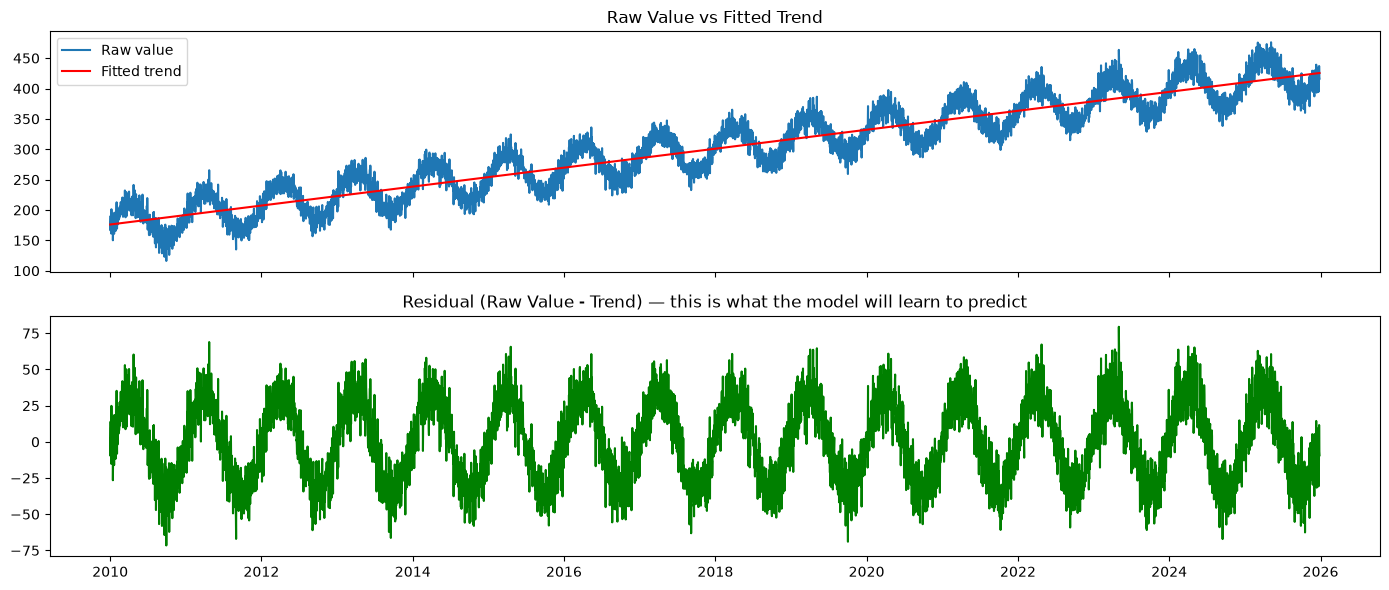

In [5]:
# Sanity check: residual should be flat/stationary (no more upward drift), unlike the raw value.
# (Showing just `value` here — the same pattern holds for customers/invoice_count/units.)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)  # Figure with 2 stacked subplots sharing the same x-axis (dates)

axes[0].plot(df.index, df["value"], label="Raw value")                              # Top subplot: the original raw series
axes[0].plot(df.index, df["value_trend"], label="Fitted trend", color="red")        # ...with the fitted trend line overlaid
axes[0].set_title("Raw Value vs Fitted Trend")
axes[0].legend()

axes[1].plot(df.index, df["value_residual"], color="green")  # Bottom subplot: what's left after removing the trend
axes[1].set_title("Residual (Raw Value - Trend) — this is what the model will learn to predict")
plt.tight_layout()


In [6]:
# Scale ALL feature columns to [0, 1] together — fit the scaler ONLY on the training portion to avoid data leakage
# (fitting on the full series would let the scaler "see" the test period's min/max)

from sklearn.preprocessing import MinMaxScaler  # MinMaxScaler rescales values into [0, 1] using (x - min) / (max - min)

# The columns the model will actually see. Column 0 is the TARGET (what we predict);
# columns 1-4 are extra predictor features that give the model more context.
FEATURE_COLS = ["value_residual", "customers_residual", "invoice_count_residual", "units_residual", "discount"]
TARGET_COL_IDX = 0  # index of "value_residual" within FEATURE_COLS

scaler = MinMaxScaler()  # Create the scaler object — it hasn't learned any min/max yet
scaler.fit(df[FEATURE_COLS].iloc[:raw_split])          # "fit" = compute min & max PER COLUMN, using only the training rows
scaled_values = scaler.transform(df[FEATURE_COLS])      # "transform" = apply each column's min/max formula to the FULL series (train + test)
scaled_values.shape   # (5840, 5) -> one row per day, one column per feature

def scale_column(raw_values, col_idx):
    # Scale a single 1D array using the SAME min/max that `scaler` already learned for that column index,
    # without needing to build a dummy 5-column array just to call scaler.transform().
    return (raw_values - scaler.data_min_[col_idx]) / (scaler.data_max_[col_idx] - scaler.data_min_[col_idx])

def inverse_scale_column(scaled_values_1d, col_idx):
    # The reverse of scale_column: turn a scaled 1D array back into real units for that column index.
    return scaled_values_1d * (scaler.data_max_[col_idx] - scaler.data_min_[col_idx]) + scaler.data_min_[col_idx]


In [7]:
# Create sliding windows: use `window_size` past days (ALL 5 features) to predict the next day's TARGET feature

def create_windows(series, window_size, target_col=0):
    X, y = [], []  # X holds the multi-feature input windows, y holds the single target value for each window
    for i in range(len(series) - window_size):             # Slide a window across the series, one step at a time
        X.append(series[i:i + window_size])                  # Input: window_size consecutive days, ALL feature columns
        y.append(series[i + window_size, target_col])         # Target: only the TARGET column of the very next day
    return np.array(X), np.array(y).reshape(-1, 1)   # X: (num_windows, window_size, num_features), y: (num_windows, 1)

window_size = 30   # Use the past 30 days to predict day 31
X, y = create_windows(scaled_values, window_size, target_col=TARGET_COL_IDX)
X.shape, y.shape   # X: (num_windows, 30, 5) -> (samples, timesteps, features). y: (num_windows, 1)


((5810, 30, 5), (5810, 1))

In [8]:
# Chronological train/test split (no shuffling for time series)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape, X_test.shape

((4648, 30, 5), (1162, 30, 5))

## Build the Transformer

We're modelling 5 detrended/scaled features (`value_residual`, `customers_residual`, `invoice_count_residual`, `units_residual`, `discount`) with a small Transformer encoder, predicting only `value_residual`:
- **Positional encoding** — self-attention has no built-in sense of order, so we inject sin/cos position signals into the input.
- **Multi-head self-attention** — lets each day in the 30-day window attend to every other day in the window.
- **Feedforward + residual + layer norm** — the standard Transformer block, stacked twice here.
- A final pooling + dense head predicts the next day's (scaled) `value_residual`, using all 5 input features as context.

In [9]:
# Transformer building blocks

import tensorflow as tf  # TensorFlow: the deep learning framework used to build and train the neural network
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
# Input:                  defines the shape of data going into the model
# Dense:                  a standard fully-connected neural network layer
# Dropout:                randomly "turns off" some neurons during training to prevent overfitting
# LayerNormalization:     normalizes values within each sample so training is more stable
# MultiHeadAttention:     the core Transformer building block — lets the model relate different time steps to each other
# GlobalAveragePooling1D: averages across the time dimension to collapse a sequence into a single vector

from tensorflow.keras.models import Model              # Model: wraps our layers into a trainable Keras model
from tensorflow.keras.callbacks import EarlyStopping   # EarlyStopping: stops training automatically once the model stops improving

def positional_encoding(seq_len, d_model):
    # Self-attention has NO built-in concept of order — if you shuffled the 30 days in a window,
    # attention would treat it the same. Positional encoding injects information about EACH position
    # (day 1, day 2, ... day 30) into the data, using a fixed pattern of sine and cosine waves.

    positions = np.arange(seq_len)[:, np.newaxis]
    # np.arange(seq_len) makes [0, 1, 2, ..., seq_len-1] — one number per time step, a flat 1D array
    # with shape (seq_len,).
    # `[:, np.newaxis]` inserts a new axis in the second position, reshaping it from (seq_len,) to
    # (seq_len, 1) — i.e. turns a flat list into a column vector (seq_len rows, 1 column).
    # We do this so it can be "broadcast" (matched up element-by-element) against `dims` below.

    dims = np.arange(d_model)[np.newaxis, :]


    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    # Computes a different "frequency" for each embedding dimension. Lower dimensions get fast-changing
    # (high frequency) waves, higher dimensions get slow-changing (low frequency) waves — this mix of
    # frequencies is what lets the model tell positions apart later. Shape: (1, d_model).

    angle_rads = positions * angle_rates
    # Multiplies the (seq_len, 1) positions by the (1, d_model) angle_rates. NumPy broadcasts this into
    # a full (seq_len, d_model) matrix: each row = one time step, each column = one embedding dimension,
    # each cell = "position * frequency for that dimension" (in radians).

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])  # Every EVEN column (0, 2, 4, ...): apply sine
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])  # Every ODD column (1, 3, 5, ...): apply cosine
    # Alternating sine/cosine is the standard Transformer positional-encoding trick — it gives every
    # position a unique, smoothly-varying "fingerprint" across the d_model dimensions.

    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)
    # `angle_rads[np.newaxis, ...]` adds a new first dimension (the "batch" dimension), turning shape
    # (seq_len, d_model) into (1, seq_len, d_model). The "..." means "keep every other existing
    # dimension exactly as it is". Keras layers expect a batch dimension, even if it's just size 1
    # (it will automatically broadcast/repeat across however many samples are in the real batch).
    # `tf.cast` converts the NumPy array into a TensorFlow float32 tensor so it can be used inside the model.


In [10]:
# One Transformer encoder block: multi-head self-attention + feedforward, both with residual + layernorm

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # --- Multi-head self-attention sub-layer ---
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    # "Self"-attention: both the query and the key/value are `inputs` itself, meaning every time step
    # looks at every other time step (including itself) in the SAME window to decide what to pay attention to.
    # num_heads = how many independent attention "perspectives" run in parallel.
    # key_dim = the size of each head's internal representation.

    x = Dropout(dropout)(x)  # Randomly zero out some attention outputs during training, to reduce overfitting

    x = LayerNormalization(epsilon=1e-6)(x + inputs)
    # "x + inputs" is a RESIDUAL (skip) connection: we add the original input back to the attention output.
    # This helps gradients flow during training and lets the model default to "pass input through unchanged"
    # if attention isn't helpful for a given case. LayerNormalization then rescales the result for stability.
    # epsilon=1e-6 is a tiny number added during normalization to avoid dividing by zero.

    # --- Feedforward sub-layer ---
    ff = Dense(ff_dim, activation="relu")(x)   # Expand to a larger hidden size (ff_dim) with a ReLU activation
    ff = Dense(inputs.shape[-1])(ff)            # Project back down to the original feature size, so shapes still match for the next residual add
    ff = Dropout(dropout)(ff)                    # Dropout again, for regularization

    return LayerNormalization(epsilon=1e-6)(x + ff)
    # Another residual connection (x + ff) followed by normalization — same pattern as above.


In [11]:
# Build the full Transformer model for time series forecasting

def build_transformer_model(window_size, num_features, d_model=32, num_heads=2, ff_dim=64, num_blocks=2, dropout=0.1):
    inputs = Input(shape=(window_size, num_features))
    # Defines the expected input shape: window_size time steps, each with `num_features` values
    # (here: value_residual, customers_residual, invoice_count_residual, units_residual, discount)

    x = Dense(d_model)(inputs)
    # Project each day's feature vector (num_features numbers) up into a richer d_model-dimensional
    # representation (32 numbers). This gives the attention mechanism more "room" to encode patterns,
    # and also means the model automatically learns how to weigh/combine the different input features.

    x = x + positional_encoding(window_size, d_model)
    # Add the fixed sine/cosine positional encoding (same shape as x) so the model knows the ORDER of the days,
    # since attention alone has no built-in sense of sequence order.

    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size=d_model // num_heads, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
    # Stack `num_blocks` Transformer encoder blocks one after another (here: 2), each refining the representation further.
    # head_size = d_model // num_heads splits the d_model-sized representation evenly across the attention heads.

    x = GlobalAveragePooling1D()(x)
    # We now have one vector per time step (30 of them). Average them all into a SINGLE vector,
    # collapsing the time dimension so we can make one final prediction.

    x = Dense(32, activation="relu")(x)   # A regular hidden layer to combine the pooled features
    x = Dropout(dropout)(x)                # More regularization
    outputs = Dense(1)(x)                   # Final output: a single number — the predicted (scaled) TARGET residual for the next day

    model = Model(inputs, outputs)   # Wrap the input -> output pipeline into a trainable Keras Model
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    # optimizer="adam": the algorithm that updates the model's weights during training
    # loss="mse": Mean Squared Error — what the model tries to minimize (standard choice for regression)
    # metrics=["mae"]: Mean Absolute Error — also tracked for human-readable reporting (not used to update weights)
    return model

model = build_transformer_model(window_size, num_features=X_train.shape[-1])
model.summary()  # Print a table of every layer, its output shape, and its parameter count


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 32)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 32)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 32)    │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 32)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 32)    │      2,080 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 32)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0] 

 Total params: 18,369 (71.75 KB)

 Trainable params: 18,369 (71.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, min_delta=0.01)
# monitor="val_loss": watch the validation loss after every epoch
# patience=5: stop if val_loss hasn't improved by at least `min_delta` for 5 epochs in a row
# min_delta=0.01: the minimum improvement in val_loss required to count as "still improving"
# restore_best_weights=True: after stopping, roll the model back to the epoch with the best val_loss (not just the last epoch)

history = model.fit(
    X_train, y_train,                    # Training inputs and targets
    validation_data=(X_test, y_test),    # Data used ONLY to monitor performance each epoch (never used to update weights)
    epochs=1000,                          # Maximum passes over the training data (EarlyStopping will almost certainly stop it much sooner)
    batch_size=64,                        # Number of samples processed before each weight update
    callbacks=[early_stop],               # Attach the EarlyStopping rule defined above
    verbose=1                             # Print a progress bar/log line for every epoch
)
# `history` stores the loss/metric values for every epoch, so we can plot training curves later if we want to.


Epoch 1/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.0669 - mae: 0.1762 - val_loss: 0.0130 - val_mae: 0.0916
Epoch 2/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0165 - mae: 0.1020 - val_loss: 0.0115 - val_mae: 0.0871
Epoch 3/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0149 - mae: 0.0975 - val_loss: 0.0107 - val_mae: 0.0832
Epoch 4/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0145 - mae: 0.0952 - val_loss: 0.0102 - val_mae: 0.0814
Epoch 5/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0132 - mae: 0.0912 - val_loss: 0.0101 - val_mae: 0.0808
Epoch 6/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0127 - mae: 0.0897 - val_loss: 0.0098 - val_mae: 0.0796


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


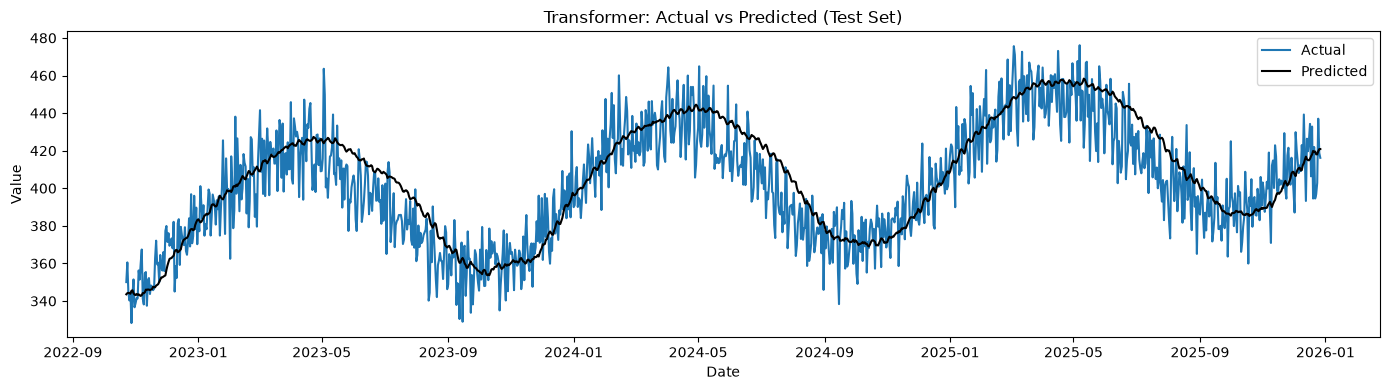

In [13]:
# Evaluate on the held-out test set — model predicts value_residual, so add the trend back to reconstruct the real value

test_resid_pred_scaled = model.predict(X_test)
# Run the trained model on the test windows. Output shape: (num_test_samples, 1), still in scaled units for value_residual.

test_resid_pred = inverse_scale_column(test_resid_pred_scaled.flatten(), TARGET_COL_IDX)
# Undo scaling for JUST the target column (value_residual), using the helper defined earlier
# (we can't use scaler.inverse_transform directly here since the scaler was fit on all 5 columns at once).

test_dates = df.index[-len(y_test):]
# Grab the actual calendar dates that correspond to the test targets. Since our windows/split are
# chronological, the LAST len(y_test) rows of df line up exactly with the test targets.

test_trend = df["value_trend"].values[-len(y_test):]
# The (already-fitted) trend value for those same test dates.

test_pred_value = test_resid_pred + test_trend        # residual + trend = reconstructed prediction, in real units
test_actual_value = df["value"].values[-len(y_test):]   # true raw value, for comparison

plt.figure(figsize=(14, 4))
plt.plot(test_dates, test_actual_value, label="Actual")
plt.plot(test_dates, test_pred_value, label="Predicted", color="k")
plt.title("Transformer: Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()


In [14]:
# Recursive (autoregressive) multi-step forecasting of the TARGET (value_residual) only:
# predict 1 step ahead, slide the window forward with that prediction, repeat.
# Then add the EXTRAPOLATED trend back to get the final forecast in real units.
#
# IMPORTANT: to build each future window we need ALL 5 features for that day, but the model only
# predicts the target (value_residual) — the other 4 columns (customers, invoice_count, units, discount)
# are treated as "known" future covariates here, using the SAME synthetic generators used to create the
# historical data. This is a simplification that only works because the data is synthetic: in a real
# business, `discount` might genuinely be known in advance (a planned promo calendar), but customers/
# invoice_count/units would normally need their own forecast or a real external plan/projection.

n_future = 365 * 3  # How many days ahead to forecast (currently set to 3 years)
future_t = np.arange(len(df), len(df) + n_future)  # Day-index counter continuing on from where history left off

# --- Regenerate the "known" future covariates using the same formulas as the original data generation ---
future_customers = 200 + 0.05 * future_t + 20 * np.sin(2 * np.pi * future_t / 7) + 40 * np.sin(2 * np.pi * future_t / 365.25)
future_invoice_count = future_customers * 1.1
future_units = future_invoice_count * 3
future_discount = np.clip(12 + 5 * np.sin(2 * np.pi * future_t / 7), 0, 30)

# --- Detrend customers/invoice_count/units using the trend lines ALREADY fitted on training data ---
future_customers_resid = future_customers - np.polyval(trend_coeffs["customers"], future_t)
future_invoice_count_resid = future_invoice_count - np.polyval(trend_coeffs["invoice_count"], future_t)
future_units_resid = future_units - np.polyval(trend_coeffs["units"], future_t)

# --- Scale each future covariate with the SAME per-column min/max the scaler learned on training data ---
future_covariates_scaled = np.stack([
    scale_column(future_customers_resid, 1),      # column 1 = customers_residual
    scale_column(future_invoice_count_resid, 2),   # column 2 = invoice_count_residual
    scale_column(future_units_resid, 3),           # column 3 = units_residual
    scale_column(future_discount, 4),              # column 4 = discount
], axis=1)  # shape (n_future, 4) — one row per future day, one column per non-target feature

def forecast_target(model, last_window, future_covariates_scaled, window_size, target_col=0):
    window = last_window.copy()
    # Start from the last known 30-day window (ALL 5 scaled features). .copy() so we don't
    # accidentally modify the original `scaled_values` array while we update `window` below.

    predictions = []
    for day in range(len(future_covariates_scaled)):   # Repeat once per future day we want to forecast
        pred = model.predict(window.reshape(1, window_size, window.shape[-1]), verbose=0)
        # Reshape the flat window into (1, window_size, num_features) — the exact shape the model expects.

        pred_value = pred[0, 0]
        predictions.append(pred_value)
        # model.predict returns shape (1, 1) — grab the single scalar target prediction out of it.

        new_row = np.empty(window.shape[-1])
        new_row[target_col] = pred_value              # the model's own prediction for the target column
        other_cols = [i for i in range(window.shape[-1]) if i != target_col]
        new_row[other_cols] = future_covariates_scaled[day]   # "known" covariates for this future day

        window = np.append(window[1:], new_row.reshape(1, -1), axis=0)
        # Slide the window forward by one day: drop the OLDEST row, append the new (predicted target +
        # known covariates) row. This is what makes the forecast "autoregressive" for the target column.

    return np.array(predictions).reshape(-1, 1)

last_window = scaled_values[-window_size:]   # The most recent 30 days (all 5 scaled features) — the starting point for forecasting

future_resid_scaled = forecast_target(model, last_window, future_covariates_scaled, window_size, target_col=TARGET_COL_IDX)
future_resid = inverse_scale_column(future_resid_scaled.flatten(), TARGET_COL_IDX)
# Undo scaling to get the forecasted value_residual back in real units, as a flat 1D array.

future_trend = np.polyval(trend_coeffs["value"], future_t)
# Evaluate the SAME straight-line trend equation (fitted earlier on training data) at these future
# day-indices. This extrapolates the trend forward in time.

future_values = future_resid + future_trend
# Add the model's predicted residual to the extrapolated trend -> final forecast in real units.

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=n_future, freq="D")
# Generate the actual calendar dates for the forecast period, starting the day after our last known date.

future_df = pd.DataFrame({"date": future_dates, "value": future_values}).set_index("date")
# Package the forecast into a DataFrame indexed by date, matching the style of our original `df`.
future_df.head()


,value
date,
2025-12-28,421.137358
2025-12-29,420.758664
2025-12-30,419.650326
2025-12-31,420.141987
2026-01-01,422.377519


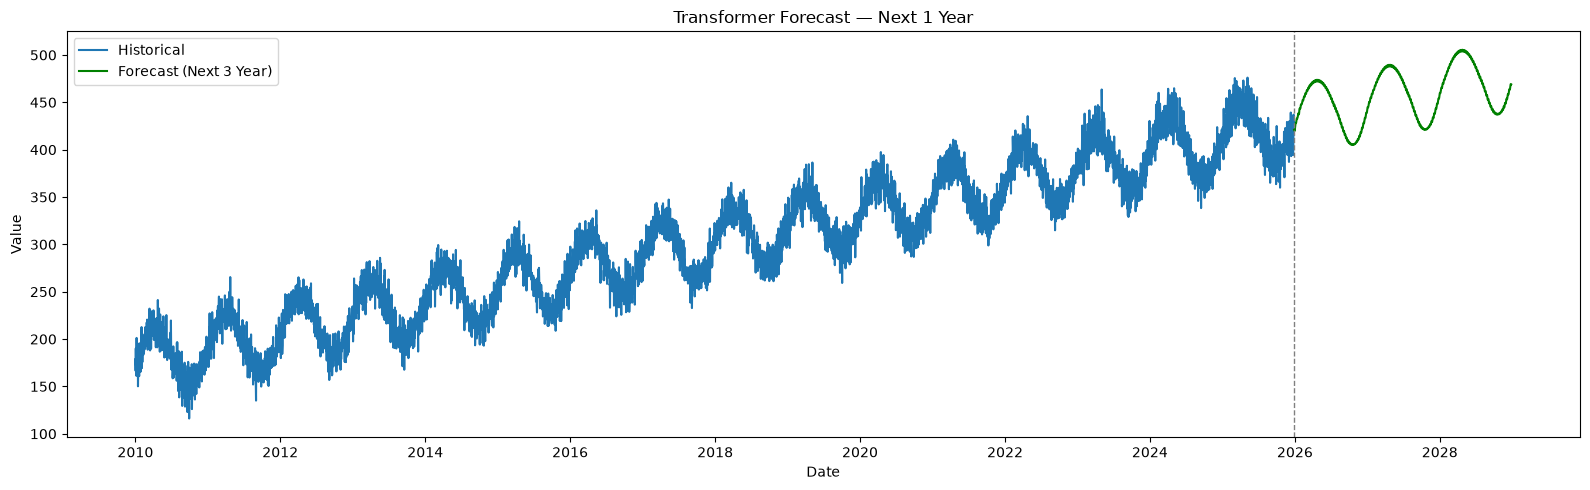

In [15]:
# Plot full history + next-3-year forecast

plt.figure(figsize=(16, 5))
plt.plot(df.index, df["value"], label="Historical")                                    # The full known history
plt.plot(future_df.index, future_df["value"], label="Forecast (Next 3 Year)", color="green")  # The forecasted future
plt.axvline(df.index[-1], color="gray", linestyle="--", linewidth=1)
# Draw a vertical dashed line marking exactly where history ends and forecast begins

plt.title("Transformer Forecast — Next 1 Year")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()


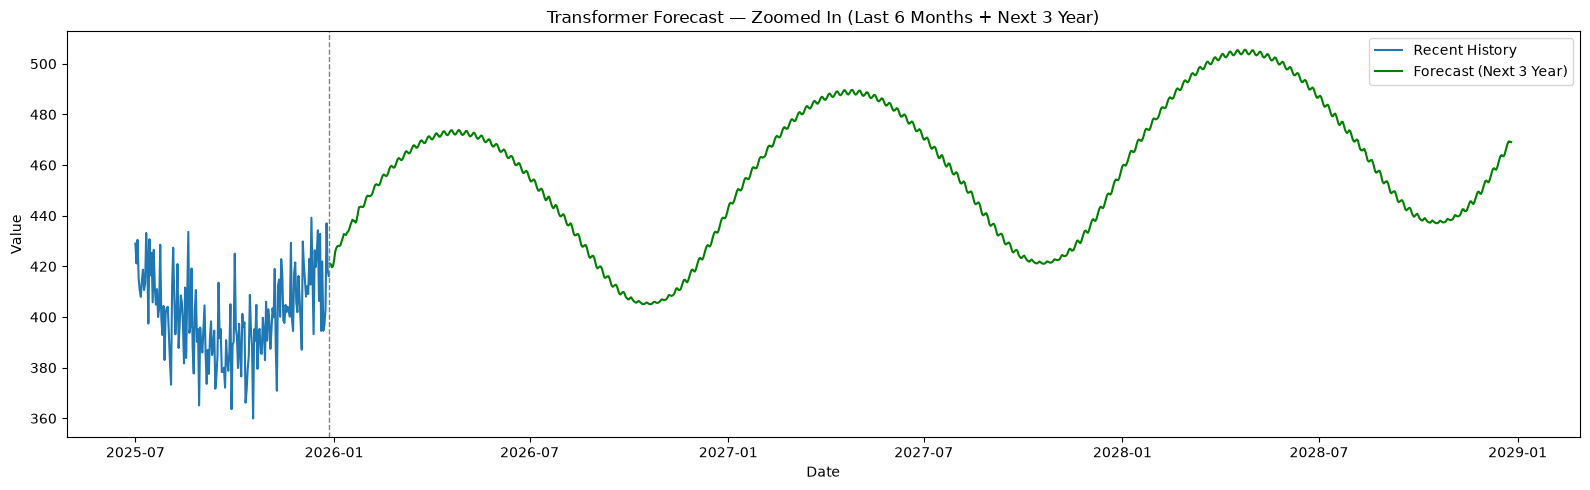

In [16]:
# Zoomed-in view: last 6 months of history + full forecast (easier to read than the full 16-year plot)

recent_history = df.iloc[-180:]
# .iloc[-180:] selects the last 180 ROWS by position (not by date/label) — roughly the last 6 months of daily data

plt.figure(figsize=(16, 5))
plt.plot(recent_history.index, recent_history["value"], label="Recent History")
plt.plot(future_df.index, future_df["value"], label="Forecast (Next 3 Year)", color="green")
plt.axvline(df.index[-1], color="gray", linestyle="--", linewidth=1)
plt.title("Transformer Forecast — Zoomed In (Last 6 Months + Next 3 Year)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
